## 1. Import Libraries

In [173]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report


## 2. Load Dataset

In [174]:
df = pd.read_csv("/content/train.csv")

## 3. Exploratory Data Analysis (EDA)

In [175]:
df.shape


(891, 12)

In [176]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [177]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


### Target Class Distribution

In [178]:
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


### Missing Values

In [179]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [180]:
df['Pclass'].unique()

array([3, 1, 2])

In [181]:
df['Sex'].unique()

array(['male', 'female'], dtype=object)

In [182]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Feature Correlation With Survival

In [183]:
df['Age'].corr(df['Survived'])

np.float64(-0.07722109457217768)

In [184]:
df.corr(numeric_only = True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


### Filling Missing Age

In [185]:
df.groupby(['Pclass', 'Sex'])['Age'].median()

Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64

In [186]:
df.groupby(['Pclass', 'Sex'])['Age'].mean()

Pclass  Sex   
1       female    34.611765
        male      41.281386
2       female    28.722973
        male      30.740707
3       female    21.750000
        male      26.507589
Name: Age, dtype: float64

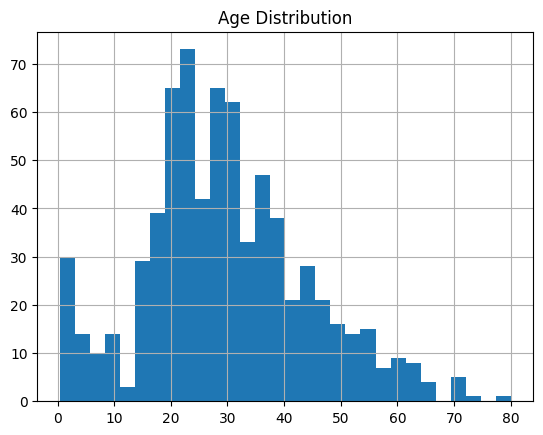

Mean: 29.7
Median: 28.0


In [187]:
df["Age"].hist(bins=30)
plt.title("Age Distribution")
plt.show()

print(f"Mean: {df['Age'].mean():.1f}")
print(f"Median: {df['Age'].median():.1f}")

In [188]:
df["Age"] = df["Age"].fillna(df.groupby(["Pclass", "Sex"])["Age"].transform("mean"))

In [189]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Investigating Embarked

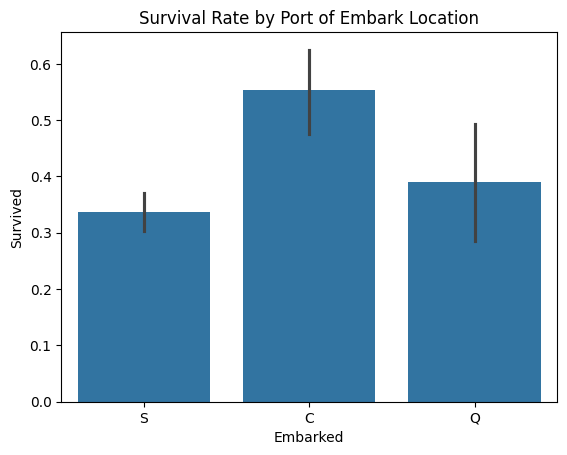

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


In [190]:
sns.barplot(data=df, x="Embarked", y="Survived")
plt.title("Survival Rate by Port of Embark Location")
plt.show()

print(df.groupby("Embarked")["Survived"].mean())

### Filling Missing Embarked

In [191]:
df["Embarked"] = df["Embarked"].fillna(df.groupby("Pclass")["Embarked"].transform(lambda x: x.mode()[0] if not x.mode().empty else "S"))

In [192]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


###Dropping Cabin
Most Cabin values are missing. Too much to fill.

In [193]:
df = df.drop(columns= "Cabin" )

In [194]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


## Feature Engineering

###Family Size

In [195]:
df["Family_size"] = df["SibSp"] + df["Parch"] + 1

In [196]:
df = df.drop(columns=["SibSp", "Parch"])

In [197]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,Family_size
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,A/5 21171,7.2500,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,PC 17599,71.2833,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,STON/O2. 3101282,7.9250,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,113803,53.1000,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,373450,8.0500,S,1


In [198]:
df["Age"] = df["Age"].astype(int)

In [199]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,Family_size
0,1,0,3,"Braund, Mr. Owen Harris",male,22,A/5 21171,7.2500,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,PC 17599,71.2833,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26,STON/O2. 3101282,7.9250,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,113803,53.1000,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35,373450,8.0500,S,1


###Investigating Fare

In [200]:
print(df.groupby("Survived")["Fare"].mean())

Survived
0    22.117887
1    48.395408
Name: Fare, dtype: float64


In [201]:
df.describe()

,PassengerId,Survived,Pclass,Age,Fare,Family_size
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.191919,32.204208,1.904602
std,257.353842,0.486592,0.836071,13.313598,49.693429,1.613459
min,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,223.500000,0.000000,2.000000,21.000000,7.910400,1.000000
50%,446.000000,0.000000,3.000000,26.000000,14.454200,1.000000
75%,668.500000,1.000000,3.000000,36.000000,31.000000,2.000000
max,891.000000,1.000000,3.000000,80.000000,512.329200,11.000000


In [202]:
df.sort_values("Fare", ascending= False)

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,Family_size
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36,PC 17755,512.3292,C,2
258,259,1,1,"Ward, Miss. Anna",female,35,PC 17755,512.3292,C,1
737,738,1,1,"Lesurer, Mr. Gustave J",male,35,PC 17755,512.3292,C,1
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23,19950,263.0000,S,6
438,439,0,1,"Fortune, Mr. Mark",male,64,19950,263.0000,S,6
...,...,...,...,...,...,...,...,...,...,...
806,807,0,1,"Andrews, Mr. Thomas Jr",male,39,112050,0.0000,S,1
815,816,0,1,"Fry, Mr. Richard",male,41,112058,0.0000,S,1
466,467,0,2,"Campbell, Mr. William",male,30,239853,0.0000,S,1
481,482,0,2,"Frost, Mr. Anthony Wood ""Archie""",male,30,239854,0.0000,S,1


count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64


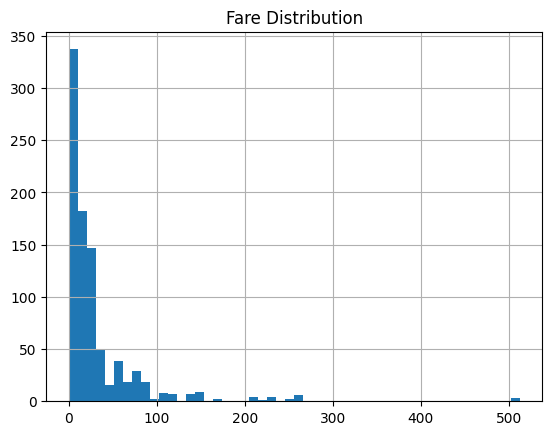

In [203]:
print(df["Fare"].describe())

df["Fare"].hist(bins=50)
plt.title("Fare Distribution")
plt.show()

In [204]:
df[df['Fare']==0][['Fare', 'Survived', 'Pclass']]

,Fare,Survived,Pclass
179,0.0,0,3
263,0.0,0,1
271,0.0,1,3
277,0.0,0,2
302,0.0,0,3
413,0.0,0,2
466,0.0,0,2
481,0.0,0,2
597,0.0,0,3
633,0.0,0,1


In [205]:
df = df[df['Fare'] > 0]

In [206]:
df.shape

(876, 10)

In [207]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 876 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  876 non-null    int64  
 1   Survived     876 non-null    int64  
 2   Pclass       876 non-null    int64  
 3   Name         876 non-null    object 
 4   Sex          876 non-null    object 
 5   Age          876 non-null    int64  
 6   Ticket       876 non-null    object 
 7   Fare         876 non-null    float64
 8   Embarked     876 non-null    object 
 9   Family_size  876 non-null    int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 75.3+ KB


In [208]:
df.describe()

,PassengerId,Survived,Pclass,Age,Fare,Family_size
count,876.000000,876.000000,876.000000,876.000000,876.000000,876.000000
mean,444.794521,0.389269,2.315068,29.111872,32.755650,1.920091
std,257.806393,0.487863,0.835663,13.378663,49.936826,1.622839
min,1.000000,0.000000,1.000000,0.000000,4.012500,1.000000
25%,220.750000,0.000000,2.000000,21.000000,7.925000,1.000000
50%,444.500000,0.000000,3.000000,26.000000,14.500000,1.000000
75%,667.250000,1.000000,3.000000,36.000000,31.275000,2.000000
max,891.000000,1.000000,3.000000,80.000000,512.329200,11.000000


###Log Transformation on Fare

In [209]:
df["Fare"] = np.log1p(df["Fare"])

In [210]:
df.describe()

,PassengerId,Survived,Pclass,Age,Fare,Family_size
count,876.000000,876.000000,876.000000,876.000000,876.000000,876.000000
mean,444.794521,0.389269,2.315068,29.111872,3.012969,1.920091
std,257.806393,0.487863,0.835663,13.378663,0.895628,1.622839
min,1.000000,0.000000,1.000000,0.000000,1.611935,1.000000
25%,220.750000,0.000000,2.000000,21.000000,2.188856,1.000000
50%,444.500000,0.000000,3.000000,26.000000,2.740840,1.000000
75%,667.250000,1.000000,3.000000,36.000000,3.474293,2.000000
max,891.000000,1.000000,3.000000,80.000000,6.240917,11.000000


In [211]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,Family_size
0,1,0,3,"Braund, Mr. Owen Harris",male,22,A/5 21171,2.110213,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,PC 17599,4.280593,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26,STON/O2. 3101282,2.188856,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,113803,3.990834,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35,373450,2.202765,S,1


## Encoding Categorical Variables

In [212]:
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

In [213]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,Family_size
0,1,0,3,"Braund, Mr. Owen Harris",1,22,A/5 21171,2.110213,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38,PC 17599,4.280593,C,2
2,3,1,3,"Heikkinen, Miss. Laina",0,26,STON/O2. 3101282,2.188856,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35,113803,3.990834,S,2
4,5,0,3,"Allen, Mr. William Henry",1,35,373450,2.202765,S,1


In [214]:
df = pd.get_dummies(df, columns=['Embarked'], drop_first= True)

In [215]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Family_size,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22,A/5 21171,2.110213,2,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38,PC 17599,4.280593,2,False,False
2,3,1,3,"Heikkinen, Miss. Laina",0,26,STON/O2. 3101282,2.188856,1,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35,113803,3.990834,2,False,True
4,5,0,3,"Allen, Mr. William Henry",1,35,373450,2.202765,1,False,True


##Define Features and Target

In [216]:
X =df.drop(columns = ['PassengerId', 'Survived', 'Name', 'Ticket'])

In [217]:
y = df['Survived']

## Train/Test Split

In [218]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [219]:
print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (700, 7)
Shape of X_test: (176, 7)
Shape of y_train: (700,)
Shape of y_test: (176,)


## Feature Scaling

In [220]:
scaler = RobustScaler()

In [221]:
X_train[['Age','Family_size']] = scaler.fit_transform(X_train[['Age','Family_size']])
X_test[['Age','Family_size']] = scaler.transform(X_test[['Age','Family_size']])

In [222]:
X_train

,Pclass,Sex,Age,Fare,Family_size,Embarked_Q,Embarked_S
403,3,1,0.133333,2.824351,1.0,False,True
553,3,1,-0.266667,2.107178,0.0,False,False
530,2,0,-1.600000,3.295837,2.0,False,True
780,3,0,-0.866667,2.107689,0.0,False,False
236,2,1,1.200000,3.295837,1.0,False,True
...,...,...,...,...,...,...,...
106,3,0,-0.333333,2.157559,0.0,False,True
273,1,1,0.733333,3.424263,1.0,False,False
875,3,0,-0.733333,2.107178,0.0,False,False
441,3,1,-0.400000,2.351375,0.0,False,True


## Model Training

In [223]:
model = LogisticRegression(max_iter = 1000, random_state = 42)

In [224]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [225]:
y_pred = model.predict(X_test)

## Model Evaluation

###Confusion Matrix

In [226]:
print(confusion_matrix(y_test, y_pred))

[[93 20]
 [16 47]]


## Accuracy Score

In [227]:
print(accuracy_score(y_test, y_pred))

0.7954545454545454


###Classification Report

In [228]:
print(classification_report(y_test, y_pred, target_names=["Died", "Survived"]))

              precision    recall  f1-score   support

        Died       0.85      0.82      0.84       113
    Survived       0.70      0.75      0.72        63

    accuracy                           0.80       176
   macro avg       0.78      0.78      0.78       176
weighted avg       0.80      0.80      0.80       176



## 12. Conclusion

### Results
| Metric | Score |
|--------|-------|
| Accuracy | 80% |
| F1-Score (Died) | 0.84 |
| F1-Score (Survived) | 0.72 |